In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import kagglehub

In [137]:
def dataset(handle: str) -> None:
    try:
        dataset_dir = kagglehub.dataset_download(handle) 
        print(f'Dataset {handle} downloaded to {dataset_dir}')
    except ValueError:
        dataset_dir = kagglehub.competition_download(handle)
        print(f'Dataset {handle} downloaded to {dataset_dir}')
    except Exception as e:
        print(f'Error downloading dataset: {e}')
    return dataset_dir

def load_train_df(comp):
    return pd.read_csv(comp + '/train.csv')

def load_test_df(comp):
    return pd.read_csv(comp + '/test.csv')

In [138]:
#TRAIN DATA

In [139]:
#Pandas DF
train_df=load_train_df(dataset('spaceship-titanic'))

Dataset spaceship-titanic downloaded to /Users/michellezhou/.cache/kagglehub/competitions/spaceship-titanic


In [140]:
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [141]:
train_df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')

In [142]:
train_df.shape

(8693, 14)

In [143]:
int(train_df.count().sum())

119378

In [144]:
train_df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [145]:
train_df.isna().sum().sort_values(ascending=True)

PassengerId       0
Transported       0
Age             179
RoomService     181
Destination     182
FoodCourt       183
Spa             183
VRDeck          188
Cabin           199
Name            200
HomePlanet      201
VIP             203
ShoppingMall    208
CryoSleep       217
dtype: int64

In [146]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [147]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [148]:
#TEST DATA

In [149]:
test_df = load_test_df('/Users/michellezhou/.cache/kagglehub/competitions/spaceship-titanic')

In [150]:
test_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [151]:
test_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [152]:
test_df.shape

(4277, 13)

In [153]:
int(test_df.count().sum())

54484

In [154]:
test_df.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [155]:
test_df.isna().sum().sort_values(ascending=True)

PassengerId       0
VRDeck           80
RoomService      82
HomePlanet       87
Age              91
Destination      92
CryoSleep        93
VIP              93
Name             94
ShoppingMall     98
Cabin           100
Spa             101
FoodCourt       106
dtype: int64

In [156]:
test_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [157]:
#EDA

In [158]:
TARGET = 'Transported'
FEATURES = [col for col in train_df.columns if col!=TARGET]
FEATURES

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name']

Total number of features: 13
Number of text features: 2
Number of categorical features: 4
Number of continuous features: 7


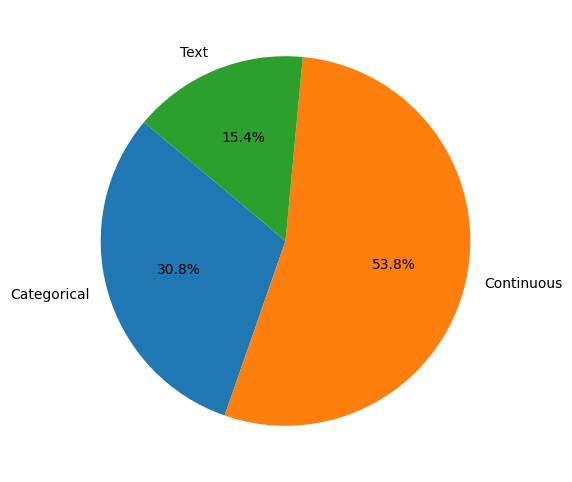

In [159]:
df = pd.concat([train_df[FEATURES], test_df[FEATURES]], axis=0)
text_features = ['Cabin', 'Name']
categorical_features = [col for col in FEATURES if df[col].nunique()<25 and col not in text_features]
continuous_features = [col for col in FEATURES if df[col].nunique()>=25 and col not in text_features]

print(f'Total number of features: {len(FEATURES)}')
print(f'Number of text features: {len(text_features)}')
print(f'Number of categorical features: {len(categorical_features)}')
print(f'Number of continuous features: {len(continuous_features)}')

categories = ['Categorical', 'Continuous', 'Text']
values = [len(categorical_features), len(continuous_features), len(text_features)]

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels = categories,
    autopct='%1.1f%%',
    startangle=140
)
plt.show()

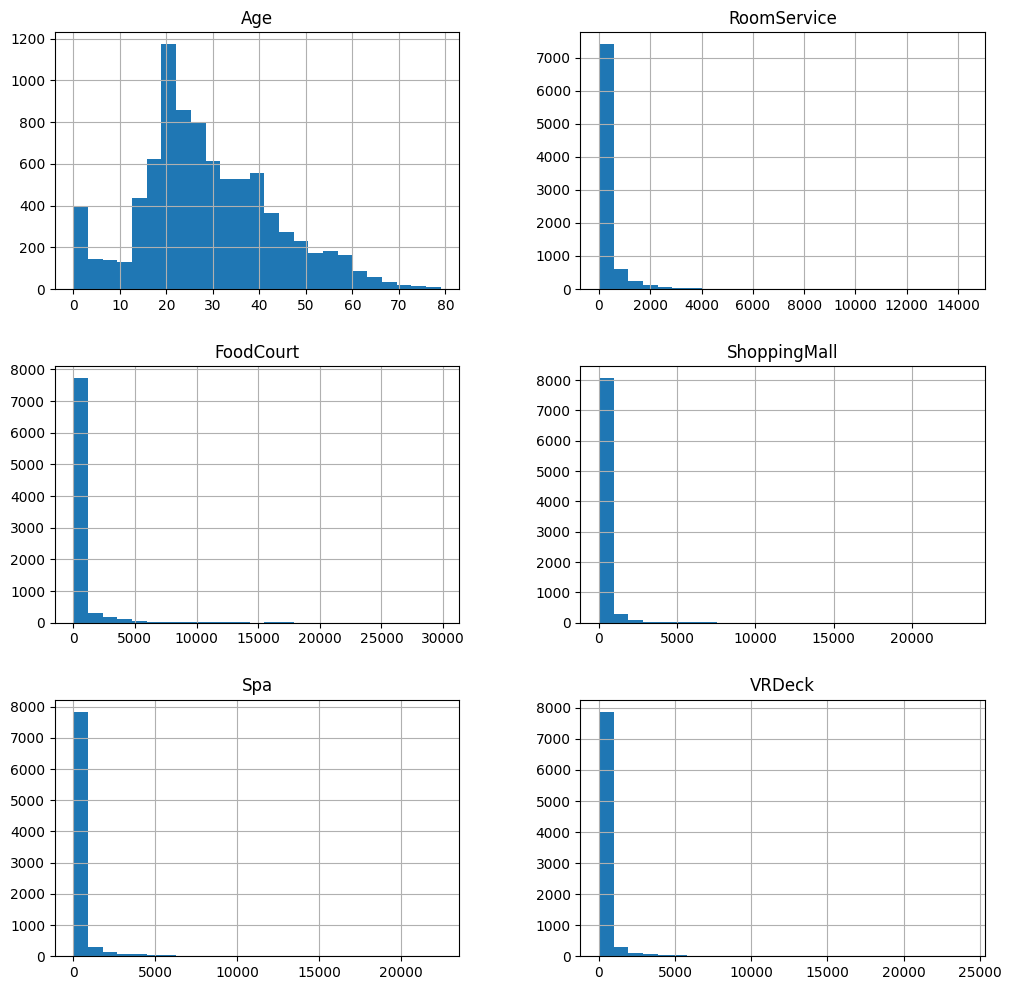

In [160]:
train_df.hist(bins = 25, figsize = (12,12))
plt.show()

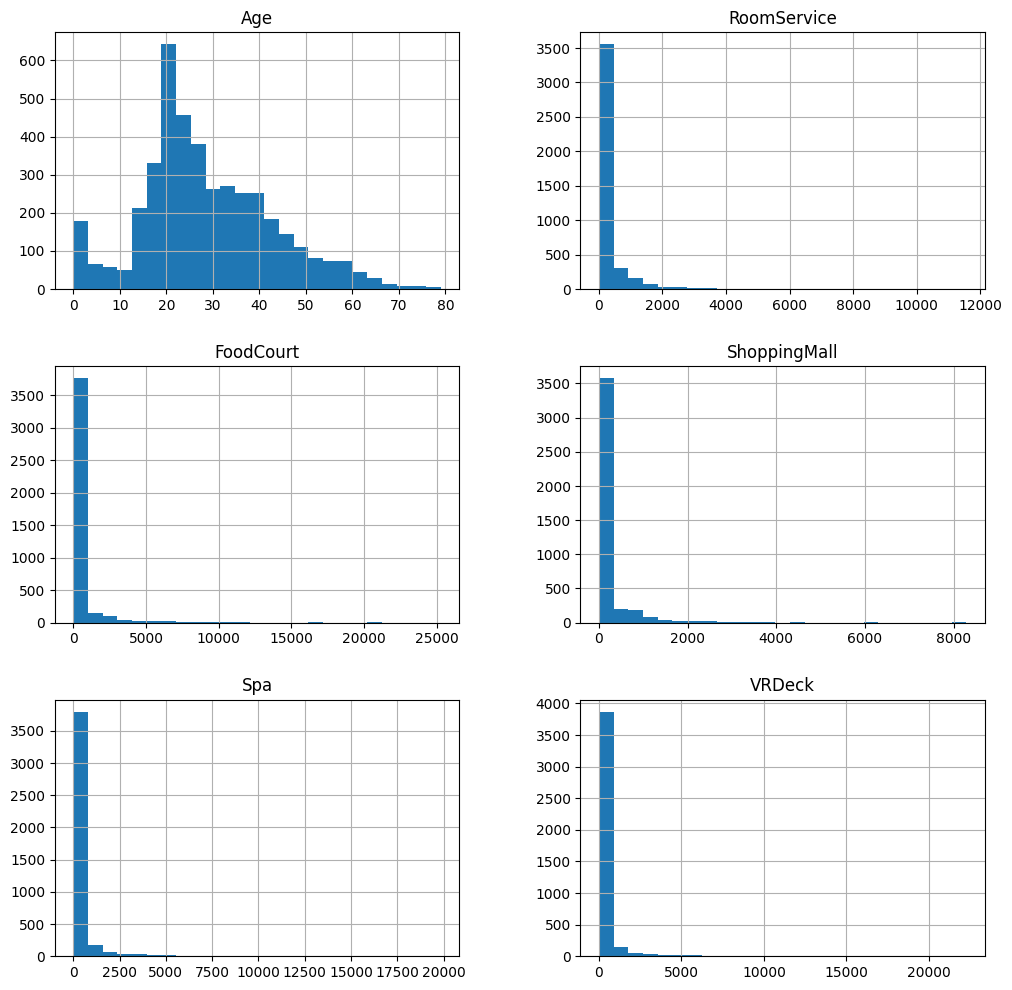

In [161]:
test_df.hist(bins = 25, figsize=(12,12))
plt.show()

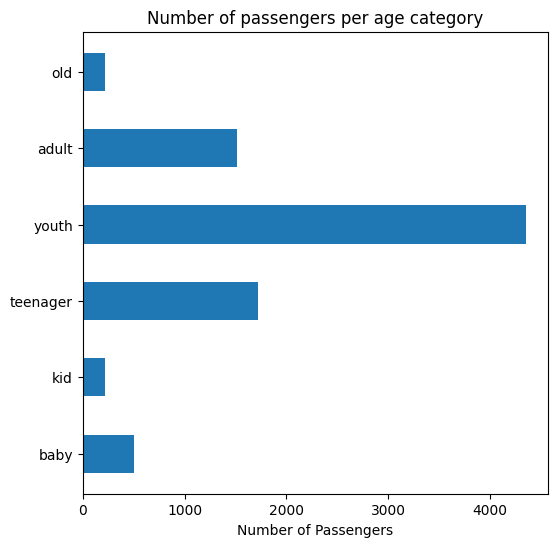

In [162]:
datasets = [train_df, test_df]
for data in datasets:
    baby = train_df[train_df['Age'] <= 5]
    kid = train_df[(train_df["Age"] > 5) & (train_df["Age"] <= 10)]
    teenager = train_df[(train_df["Age"] > 10) & (train_df["Age"] <= 20)]
    youth = train_df[(train_df["Age"] > 20) & (train_df["Age"] <= 40)]
    adult = train_df[(train_df["Age"] > 40) & (train_df["Age"] <= 60)]
    old = train_df[(train_df["Age"] > 60)]

ages = {'baby': baby.shape[0],
        'kid': kid.shape[0],
        'teenager': teenager.shape[0],
        'youth': youth.shape[0],
        'adult': adult.shape[0],
        'old': old.shape[0]
        }

ages = pd.Series(ages)

plt.figure(figsize=(6,6))
plt.title('Number of passengers per age category')
plt.xlabel('Number of Passengers')
plt.barh(ages.index, ages.values, height=0.5)
plt.show()

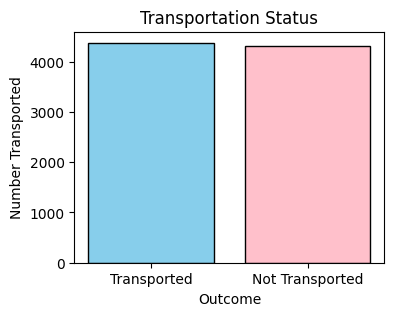

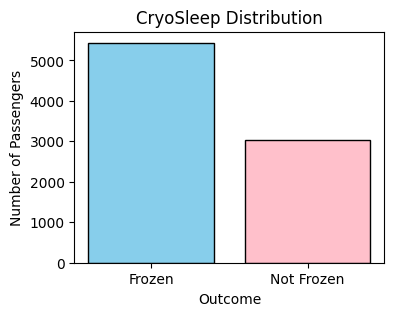

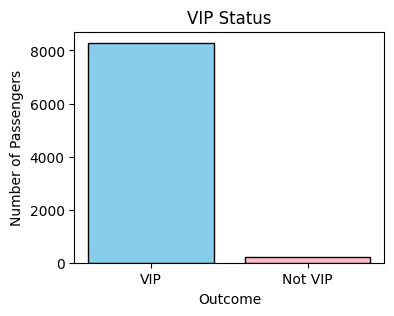

In [163]:
sizes = train_df['Transported'].value_counts()
labels = ['Transported', 'Not Transported']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('Transportation Status')
plt.xlabel('Outcome')
plt.ylabel('Number Transported')

sizes = train_df['CryoSleep'].value_counts()
labels = ['Frozen', 'Not Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

sizes = train_df['VIP'].value_counts()
labels = ['VIP', 'Not VIP']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('VIP Status')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

plt.show()

Text(0, 0.5, 'Number of Passengers')

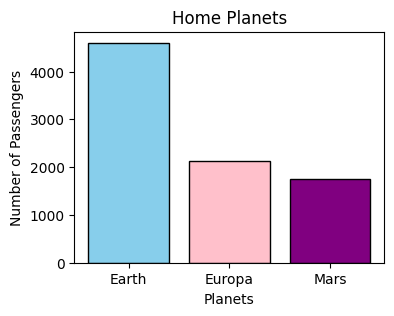

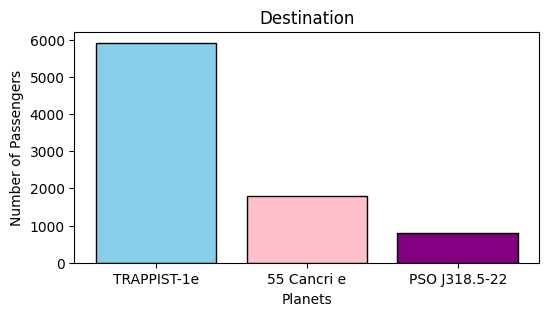

In [164]:
sizes = train_df['HomePlanet'].value_counts()
labels = list(train_df['HomePlanet'].value_counts().index)
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink', 'purple'], 
    edgecolor='black'
    )
plt.title('Home Planets')
plt.xlabel('Planets')
plt.ylabel('Number of Passengers')

sizes = train_df['Destination'].value_counts()
labels = list(train_df['Destination'].value_counts().index)
plt.figure(figsize=(6,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink', 'purple'], 
    edgecolor='black'
    )
plt.title('Destination')
plt.xlabel('Planets')
plt.ylabel('Number of Passengers')